# Per-band cross-slice correlation of the NYX SZ3 residual

Goal: check whether the **low-frequency** part of the SZ3 residual is more **cross-slice
coherent** than the high-frequency part — which would justify making the 2.5D slab focus on
the low/mid bands on NYX (idea #3).

Method: residual `R = X - X'`; split each slice into low/mid/high with the **model's own**
`_gaussian_low_mid_high_split_t` (per-slice 2D FFT, `sigma_low=0.08, sigma_mid=0.18`); then per
band measure the lag-1 Pearson correlation **along axis 0 (cross-slice = where the slab stacks)**
vs **in-plane (axes 1,2)**, plus each band's **energy share**. The slab can help a band only if
that band is both cross-slice-coherent *and* carries meaningful residual energy.

## Findings (NYX, all three fields)

| band | cross-slice (axis-0) | in-plane | ratio | energy |
|---|---|---|---|---|
| low  | 0.73–0.83 | **0.97–0.98** | **<1** | 7–11% |
| mid  | 0.51–0.75 | 0.83–0.85 | <1 | 7–10% |
| high | 0.23–0.40 | **0.01–0.15** | **2.6–24×** | **44–59%** |

**The slab helps where cross-slice > in-plane (ratio > 1), not where absolute cross-slice
correlation is highest.**

- **Low/mid bands**: the *2D model already predicts them better from in-plane* (in-plane
  corr 0.85–0.98 ≫ cross-slice). ratio < 1 → the slab's neighbor slices are **redundant** here.
  → So idea #3 ("focus the slab on low/mid") is **backwards**.
- **High band**: in-plane is essentially decorrelated (0.01–0.15), so a 2D model **cannot**
  predict it; but the residual still retains **0.23–0.40 correlation across slices** (ratio
  2.6–24×), **and the high band holds 44–59% of the residual energy**. This is the *only*
  band where the slab's 3rd-dimension view adds information the 2D path can't get — and it's
  where most of the residual lives.

**Corrected recommendation:** point the slab at the **high band** (it already uses
`bg_high_weight=1.0`), and make the slab **cheap** (idea #1: 1×1 slice-mixing front-end or
iso-param) so the *modest* high-band gain (cross-slice corr ~0.4 → ceiling is limited) isn't
eaten by the K× parameter cost / lower CR.

In [1]:
import sys, numpy as np, torch, pandas as pd, matplotlib.pyplot as plt
sys.path.append("/home/sam/Data_Compression/SZ3/tools/pysz")
sys.path.append("/home/sam/Halo_Finder/Final_design/base_script")
from pysz import SZ
from bg_sampling import _gaussian_low_mid_high_split_t   # the model's exact per-slice band split

sz_engine = SZ("/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SIGMA_LOW, SIGMA_MID = 0.08, 0.18      # same as the BG model (bg_sigma_low / bg_sigma_mid)
CORR_CROP = 384                         # centered sub-cube (speed / memory)

NYX_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin/"
NYX_SHAPE = (512, 512, 512)
NYX = {"baryon_density": 1e-6, "temperature": 1e-4, "dark_matter_density": 1e-4}
print("setup ready | device:", device)


setup ready | device: cuda


In [2]:
def _lag1_corr(R, ax):
    """lag-1 Pearson correlation of R along axis `ax` (R: np [D,H,W])."""
    a = np.moveaxis(R, ax, 0)
    x = a[:-1].reshape(-1).astype(np.float64); y = a[1:].reshape(-1).astype(np.float64)
    xs, ys = x.std(), y.std()
    if xs < 1e-12 or ys < 1e-12: return float("nan")
    return float(((x - x.mean()) * (y - y.mean())).mean() / (xs * ys))

def _band_split_volume(R, sigma_low=SIGMA_LOW, sigma_mid=SIGMA_MID, chunk=64):
    """Per-slice 2D low/mid/high split (the model's split) on a volume R: np [D,H,W]."""
    D = R.shape[0]
    out = {"low": np.empty_like(R), "mid": np.empty_like(R), "high": np.empty_like(R)}
    for s in range(0, D, chunk):
        x = torch.from_numpy(R[s:s+chunk, None]).to(device)      # [b,1,H,W]
        lo, mi, hi = _gaussian_low_mid_high_split_t(x, sigma_low, sigma_mid)
        out["low"][s:s+chunk]  = lo[:, 0].cpu().numpy()
        out["mid"][s:s+chunk]  = mi[:, 0].cpu().numpy()
        out["high"][s:s+chunk] = hi[:, 0].cpu().numpy()
    return out

def per_band_cross_slice(name, vol, rel, crop=CORR_CROP):
    sl = tuple(slice((d-min(crop,d))//2, (d-min(crop,d))//2+min(crop,d)) for d in vol.shape)
    sub = np.ascontiguousarray(np.asarray(vol[sl], np.float32))
    b, _ = sz_engine.compress(sub, 1, 0, float(rel), 0)
    R = (sub - sz_engine.decompress(b, sub.shape, np.float32)).astype(np.float32)
    bands = {"full": R, **_band_split_volume(R)}
    var_R = float(R.astype(np.float64).var()) + 1e-30
    rows = []
    for bn, Rb in bands.items():
        cross = _lag1_corr(Rb, 0)
        inpl  = float(np.nanmean([_lag1_corr(Rb, 1), _lag1_corr(Rb, 2)]))
        rows.append(dict(dataset=name, band=bn, rel=float(rel),
                         cross_slice=cross, in_plane=inpl,
                         ratio=(cross/inpl if inpl else float("nan")),
                         energy_share=float(Rb.astype(np.float64).var())/var_R))
    return rows
print("functions ready")


functions ready


done baryon_density
done temperature
done dark_matter_density
                dataset band  rel  cross_slice  in_plane  ratio  energy_share
     NYX/baryon_density full  0.0        0.588     0.547  1.074         1.000
     NYX/baryon_density  low  0.0        0.829     0.976  0.850         0.114
     NYX/baryon_density  mid  0.0        0.745     0.850  0.876         0.105
     NYX/baryon_density high  0.0        0.377     0.146  2.589         0.438
        NYX/temperature full  0.0        0.541     0.484  1.118         1.000
        NYX/temperature  low  0.0        0.734     0.973  0.754         0.071
        NYX/temperature  mid  0.0        0.694     0.833  0.833         0.100
        NYX/temperature high  0.0        0.400     0.152  2.642         0.507
NYX/dark_matter_density full  0.0        0.373     0.359  1.039         1.000
NYX/dark_matter_density  low  0.0        0.783     0.982  0.797         0.105
NYX/dark_matter_density  mid  0.0        0.507     0.840  0.604         0.068
NY

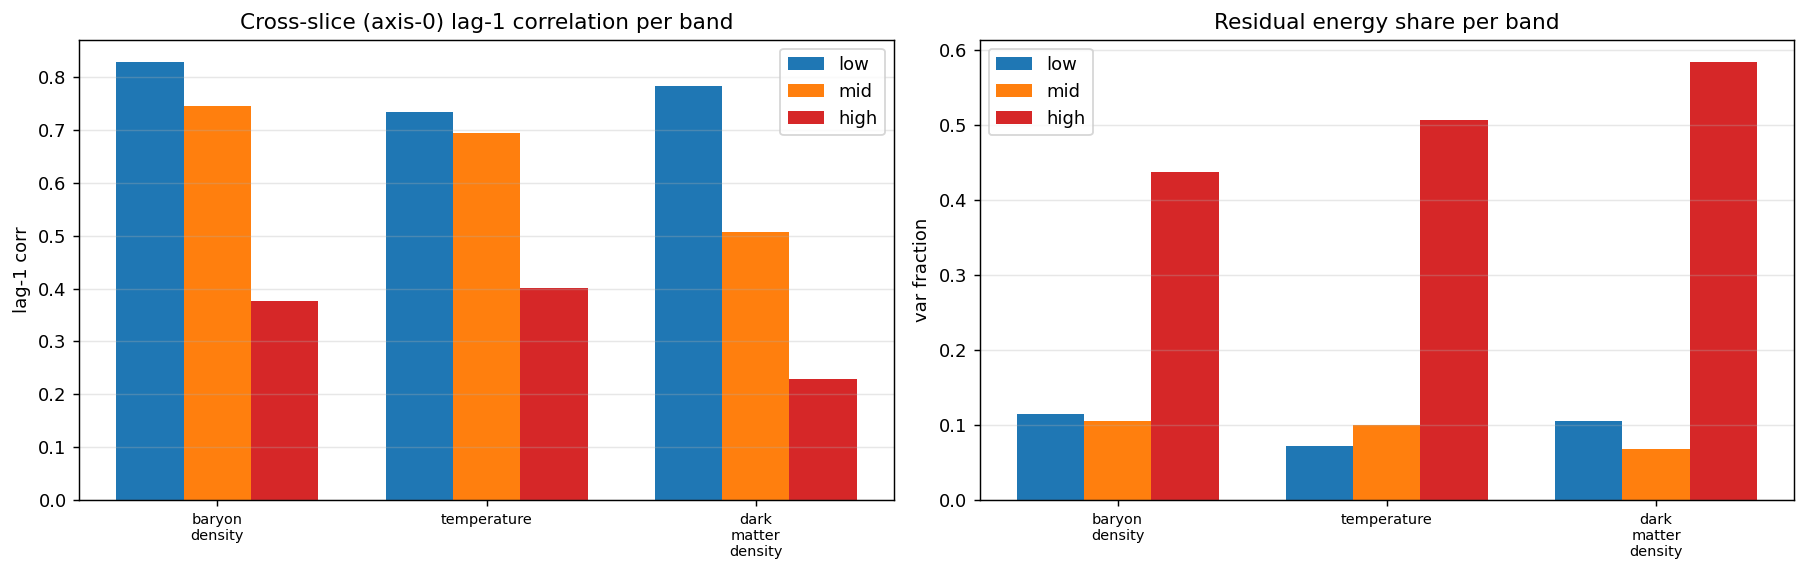

Saved: nyx_band_cross_slice_corr.pdf


In [3]:
rows = []
for fld, rel in NYX.items():
    v = np.memmap(NYX_DIR + fld + ".f32", dtype=np.float32, mode="r", shape=NYX_SHAPE)
    rows += per_band_cross_slice(f"NYX/{fld}", v, rel); del v
    print("done", fld, flush=True)

df = pd.DataFrame(rows)
pd.set_option("display.width", 160)
print(df.round(3).to_string(index=False))

# bar 1: cross-slice (axis-0) corr per band ; bar 2: energy share per band
bands = ["low", "mid", "high"]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), dpi=130)
ds = list(NYX.keys()); xp = np.arange(len(ds)); w = 0.25
cmap = {"low": "tab:blue", "mid": "tab:orange", "high": "tab:red"}
for i, bn in enumerate(bands):
    cs = [df[(df.dataset==f"NYX/{d}") & (df.band==bn)]["cross_slice"].values[0] for d in ds]
    en = [df[(df.dataset==f"NYX/{d}") & (df.band==bn)]["energy_share"].values[0] for d in ds]
    ax[0].bar(xp + (i-1)*w, cs, w, label=bn, color=cmap[bn])
    ax[1].bar(xp + (i-1)*w, en, w, label=bn, color=cmap[bn])
for a, ttl, yl in [(ax[0], "Cross-slice (axis-0) lag-1 correlation per band", "lag-1 corr"),
                   (ax[1], "Residual energy share per band", "var fraction")]:
    a.set_xticks(xp); a.set_xticklabels([d.replace("_","\n") for d in ds], fontsize=8)
    a.set_title(ttl); a.set_ylabel(yl); a.legend(); a.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("nyx_band_cross_slice_corr.pdf", bbox_inches="tight"); plt.show()
print("Saved: nyx_band_cross_slice_corr.pdf")
